# GPR Processing
**Lunar Leaper** -- Load stitched raw `.npz` data, tune processing parameters, and save the processed output.

Workflow: run cells top to bottom. Select a file, adjust sliders, then save.

In [1]:
import numpy as np
import json
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display
from pathlib import Path
from scipy.ndimage import shift as ndshift

import plotly.io as pio
pio.renderers.default = 'notebook'
from gpr_processing import apply_processing as _core_processing
widgets.Widget.close_all()

## 1. Select data
Choose a stitched `_raw.npz` file. The sidecar `.json` is loaded automatically and provenance (stitch/patch info) is printed.

In [7]:
STITCH_DIR = Path('../../Data/GPR/Stitched')
PROC_DIR   = Path('../../Data/GPR/Processed')

def get_npz_files():
    return sorted(p.name for p in STITCH_DIR.glob('*_raw.npz'))

w_file = widgets.Dropdown(
    options=get_npz_files(),
    description='File:',
    style={'description_width': '50px'},
    layout=widgets.Layout(width='420px')
)

out_load = widgets.Output()

# Globals set by load_data(), read by processing and save cells
data = dist_axis = time_axis = info = None
sfreq = nyquist = freq = suggested_dewow = None

def load_data(_=None):
    global data, dist_axis, time_axis, info, sfreq, nyquist, freq, suggested_dewow
    out_load.clear_output(wait=True)
    with out_load:
        fname = w_file.value
        if not fname:
            print('No .npz files found in', STITCH_DIR)
            return
        npz_path  = STITCH_DIR / fname
        json_path = npz_path.with_suffix('.json')
        print(f'Loading {npz_path.name}...')

        npz       = np.load(str(npz_path))
        data      = npz['data'].astype(np.float64)
        dist_axis = npz['dist_axis']
        time_axis = npz['time_axis']

        with open(str(json_path), encoding='utf-8') as f:
            info = json.load(f)

        n_samples     = info['samples']
        time_window   = info['Total_time_window']
        sfreq         = n_samples / time_window * 1000
        nyquist       = sfreq / 2
        freq          = info['Freq']
        ns_per_sample = time_window / n_samples
        suggested_dewow = round(2 / freq * 1000 / ns_per_sample)

        print(f"Shape   : {data.shape[0]} samples x {data.shape[1]} traces")
        print(f"Distance: {dist_axis[0]:.1f} - {dist_axis[-1]:.1f} {info['Pos_units']}")
        print(f"Time    : {time_axis[0]:.1f} - {time_axis[-1]:.1f} ns")
        print(f"Freq    : {freq} MHz  |  sfreq: {sfreq:.0f} MHz  |  Nyquist: {nyquist:.0f} MHz")
        print(f"Suggested dewow: {suggested_dewow} samples")

        if info.get('stitch_info'):
            segs = ', '.join(s['line'] for s in info['stitch_info']['segments'])
            print(f"\nStitched from: {segs}")
        if info.get('patch_info'):
            srcs = [p['source'] for p in info['patch_info']['patches']]
            print(f"Patches applied: {srcs}")

        if 'update_sliders' in globals():
            update_sliders()

w_file.observe(load_data, names='value')
load_data()
display(w_file)
display(out_load)

Dropdown(description='File:', layout=Layout(width='420px'), options=('FlowerPetal1_50MHz_raw.npz', 'FlowerPeta…

Output()

## 2. Interactive processing
Adjust sliders to tune the radargram. When satisfied, save in section 3.

In [3]:
# -- Processing function -------------------------------------------------------
def apply_processing(dewow_w, tzero_shift, flow, fhigh, gain_exp,
                     normalize=False, norm_start_ns=50.0, norm_end_ns=None,
                     max_time_ns=None, n_svd=0, whiten_window=0):
    return _core_processing(data, time_axis, sfreq, {
        'dewow_window':  int(dewow_w),
        'tzero_shift':   float(tzero_shift),
        'bandpass_low':  float(flow),
        'bandpass_high': float(fhigh),
        'gain_exponent': float(gain_exp),
        'normalize':     bool(normalize),
        'norm_start_ns': float(norm_start_ns),
        'norm_end_ns':   norm_end_ns,
        'max_time_ns':   max_time_ns,
        'n_svd':         int(n_svd),
        'whiten_window': int(whiten_window),
    })

# -- Widget initial values from loaded data ------------------------------------
_freq0 = freq if freq else 50
_nyq0  = nyquist if nyquist else 250
_dew0  = suggested_dewow if suggested_dewow else 15
_tz0   = -info['TZ_at_pt'] if info else 0.0
_d0    = [float(dist_axis[0]), float(dist_axis[-1])] if dist_axis is not None else [0.0, 100.0]
_n0    = info['samples'] if info else 750
_tw0   = info['Total_time_window'] if info else 800
_tmax0 = round(_tw0 * 0.8 / 5) * 5

_SW = '420px'  # slider width for column layout
_DW = '160px'  # description width

w_dewow = widgets.IntSlider(
    value=_dew0, min=1, max=150, step=1,
    description='Dewow (smp):',
    continuous_update=False,
    style={'description_width': _DW}, layout=widgets.Layout(width=_SW)
)
w_tzero = widgets.FloatSlider(
    value=_tz0, min=-200, max=100, step=0.01,
    description='Time zero (smp):',
    continuous_update=False,
    style={'description_width': _DW}, layout=widgets.Layout(width=_SW)
)
w_flow = widgets.FloatSlider(
    value=0.4 * _freq0, min=1, max=_freq0, step=1,
    description='Low cut (MHz):',
    continuous_update=False,
    style={'description_width': _DW}, layout=widgets.Layout(width=_SW)
)
w_fhigh = widgets.FloatSlider(
    value=min(2 * _freq0, _nyq0 * 0.95), min=_freq0, max=_nyq0 * 0.95, step=1,
    description='High cut (MHz):',
    continuous_update=False,
    style={'description_width': _DW}, layout=widgets.Layout(width=_SW)
)
w_gain = widgets.FloatSlider(
    value=2.5, min=0., max=3.5, step=0.1,
    description='Gain exp:',
    continuous_update=False,
    style={'description_width': _DW}, layout=widgets.Layout(width=_SW)
)
w_svd = widgets.IntSlider(
    value=0, min=0, max=5, step=1,
    description='SVD remove (n):',
    continuous_update=False,
    style={'description_width': _DW}, layout=widgets.Layout(width=_SW)
)
w_whiten_window = widgets.IntSlider(
    value=0, min=0, max=50, step=1,
    description='Whiten (bins):',
    continuous_update=False,
    style={'description_width': _DW}, layout=widgets.Layout(width=_SW)
)
w_time_max = widgets.FloatSlider(
    value=_tmax0, min=0.0, max=_tw0, step=5.0,
    description='Max time (ns):',
    continuous_update=False,
    style={'description_width': _DW}, layout=widgets.Layout(width=_SW)
)
w_normalize = widgets.Checkbox(
    value=False, description='RMS norm',
    indent=False, layout=widgets.Layout(width='90px')
)
w_norm_range = widgets.FloatRangeSlider(
    value=[50.0, _tmax0], min=0.0, max=_tw0, step=5.0,
    description='Norm window:',
    continuous_update=False,
    style={'description_width': '100px'}, layout=widgets.Layout(width='340px'),
    readout_format='.0f'
)
w_clip = widgets.FloatSlider(
    value=90, min=50, max=100, step=0.5,
    description='Clip (%):',
    continuous_update=False,
    style={'description_width': _DW}, layout=widgets.Layout(width='520px'),
    readout_format='.1f'
)
w_xrange = widgets.FloatRangeSlider(
    value=_d0, min=_d0[0], max=_d0[1], step=0.1,
    description='X range (m):',
    continuous_update=False,
    style={'description_width': _DW}, layout=widgets.Layout(width='520px'),
    readout_format='.1f'
)
w_depth_toggle = widgets.ToggleButton(
    value=False, description='Show depth', button_style='',
    layout=widgets.Layout(width='140px')
)
w_velocity = widgets.FloatSlider(
    value=0.13, min=0.05, max=0.3, step=0.005,
    description='Velocity (m/ns):',
    continuous_update=False,
    style={'description_width': _DW}, layout=widgets.Layout(width='380px'),
    readout_format='.3f'
)
w_trace_idx = widgets.IntSlider(
    value=0, min=0, max=200, step=1,
    description='Spectrum trace:',
    continuous_update=False,
    style={'description_width': _DW}, layout=widgets.Layout(width='520px')
)

out           = widgets.Output()
current_fig   = None
_cached_processed = None
_cached_proc_ng   = None
_cached_t         = None
_loading          = False

def update_sliders():
    global _loading
    _loading = True
    _f   = info['Freq']
    _nq  = sfreq / 2
    _tw  = info['Total_time_window']
    _tmax = round(_tw * 0.8 / 5) * 5
    w_flow.max    = _f
    w_flow.value  = 0.4 * _f
    w_fhigh.min   = 1
    w_fhigh.max   = _nq * 0.95
    w_fhigh.min   = _f
    w_fhigh.value = min(2 * _f, _nq * 0.95)
    w_tzero.value = -info['TZ_at_pt']
    w_dewow.value = suggested_dewow
    w_xrange.min  = dist_axis[0]
    w_xrange.max  = dist_axis[-1]
    w_xrange.value = [dist_axis[0], dist_axis[-1]]
    w_norm_range.max   = _tw
    w_norm_range.value = [50.0, _tmax]
    w_trace_idx.max    = data.shape[1] - 1
    w_trace_idx.value  = data.shape[1] // 2
    w_time_max.max     = _tw
    w_time_max.value   = _tmax
    _loading = False

# -- Combined figure -----------------------------------------------------------
def _build_figure(processed, proc_ng, time_axis_plot):
    from plotly.subplots import make_subplots

    x0, x1     = w_xrange.value
    mask        = (dist_axis >= x0) & (dist_axis <= x1)
    dist_plot   = dist_axis[mask]
    proc_plot   = processed[:, mask]
    velocity    = float(w_velocity.value)
    show_depth  = bool(w_depth_toggle.value)
    vmax        = np.percentile(np.abs(proc_plot), float(w_clip.value))
    y_radar     = time_axis_plot * velocity / 2 if show_depth else time_axis_plot
    y_label     = 'Depth (m)' if show_depth else 'Two-way travel time (ns)'
    y_hover     = 'Depth: %{y:.2f} m' if show_depth else 'Time: %{y:.1f} ns'

    dt_ns  = float(time_axis[1] - time_axis[0])
    fr_r   = np.fft.rfftfreq(data.shape[0],    d=dt_ns) * 1000
    fr_p   = np.fft.rfftfreq(proc_ng.shape[0], d=dt_ns) * 1000
    sp_r   = np.abs(np.fft.rfft(np.mean(data,    axis=1)))
    sp_p   = np.abs(np.fft.rfft(np.mean(proc_ng, axis=1)))
    fx_r   = np.abs(np.fft.rfft(data,    axis=0))
    fx_p   = np.abs(np.fft.rfft(proc_ng, axis=0))
    fxf_r  = np.fft.rfftfreq(data.shape[0],    d=dt_ns) * 1000
    fxf_p  = np.fft.rfftfreq(proc_ng.shape[0], d=dt_ns) * 1000
    clip_r = np.percentile(fx_r, 98)
    clip_p = np.percentile(fx_p, 98)
    flow   = float(w_flow.value)
    fhigh  = float(w_fhigh.value)

    dx        = float(dist_axis[1] - dist_axis[0]) if len(dist_axis) > 1 else 0.5
    k         = np.fft.fftshift(np.fft.fftfreq(processed.shape[1], d=dx))
    spec_t_r  = np.fft.rfft(data,    axis=0)
    spec_t_p  = np.fft.rfft(proc_ng, axis=0)
    fk_r      = np.abs(np.fft.fftshift(np.fft.fft(spec_t_r, axis=1), axes=1))
    fk_p      = np.abs(np.fft.fftshift(np.fft.fft(spec_t_p, axis=1), axes=1))
    fkf       = np.fft.rfftfreq(data.shape[0], d=dt_ns) * 1000
    clip_fk_r = np.percentile(fk_r, 98)
    clip_fk_p = np.percentile(fk_p, 98)

    fig = make_subplots(
        rows=4, cols=2,
        specs=[[{'colspan': 2}, None],
               [{'colspan': 2}, None],
               [{}, {}],
               [{}, {}]],
        row_heights=[0.42, 0.13, 0.22, 0.23],
        vertical_spacing=0.07,
        horizontal_spacing=0.12,
        subplot_titles=['', 'Frequency spectrum (mean trace)',
                        'f,x Raw', 'f,x Processed',
                        'f,k Raw', 'f,k Processed']
    )

    fig.add_trace(go.Heatmap(
        x=dist_plot, y=y_radar, z=proc_plot,
        colorscale='rdbu_r', zmin=-vmax, zmax=vmax,
        colorbar=dict(title='', thickness=12, len=0.30, y=0.84,
                      yanchor='middle', tickfont=dict(size=9)),
        hovertemplate='Dist: %{x:.1f} m<br>' + y_hover +
                      '<br>Amplitude: %{z:.2e}<extra></extra>'
    ), row=1, col=1)

    t_idx     = min(int(w_trace_idx.value), proc_ng.shape[1] - 1)
    sp_single = np.abs(np.fft.rfft(proc_ng[:, t_idx]))
    fr_single = np.fft.rfftfreq(proc_ng.shape[0], d=dt_ns) * 1000
    fig.add_trace(go.Scatter(x=fr_r, y=sp_r/(sp_r.max() or 1), name='Mean raw',
                              line=dict(color='gray', width=1)), row=2, col=1)
    fig.add_trace(go.Scatter(x=fr_p, y=sp_p/(sp_p.max() or 1), name='Mean proc.',
                              line=dict(color='royalblue', width=1.5)), row=2, col=1)
    fig.add_trace(go.Scatter(x=fr_single,
                              y=sp_single/(sp_single.max() or 1),
                              name=f'Trace {t_idx}',
                              line=dict(color='orange', width=1,
                                        dash='dot')), row=2, col=1)
    fig.add_vline(x=flow,  line_dash='dash', line_color='red',
                  annotation_text='Low',  row=2, col=1)
    fig.add_vline(x=fhigh, line_dash='dash', line_color='red',
                  annotation_text='High', row=2, col=1)

    fig.add_trace(go.Heatmap(x=dist_plot, y=fxf_r, z=fx_r,
                              colorscale='hot_r', zmin=0, zmax=clip_r,
                              coloraxis='coloraxis2'), row=3, col=1)
    fig.add_trace(go.Heatmap(x=dist_plot, y=fxf_p, z=fx_p,
                              colorscale='hot_r', zmin=0, zmax=clip_p,
                              coloraxis='coloraxis3'), row=3, col=2)
    for col in (1, 2):
        fig.add_hline(y=flow,  line_dash='dash', line_color='cyan', row=3, col=col)
        fig.add_hline(y=fhigh, line_dash='dash', line_color='cyan', row=3, col=col)

    fig.add_trace(go.Heatmap(x=k, y=fkf, z=fk_r,
                              colorscale='hot_r', zmin=0, zmax=clip_fk_r,
                              coloraxis='coloraxis4'), row=4, col=1)
    fig.add_trace(go.Heatmap(x=k, y=fkf, z=fk_p,
                              colorscale='hot_r', zmin=0, zmax=clip_fk_p,
                              coloraxis='coloraxis5'), row=4, col=2)
    for col in (1, 2):
        fig.add_hline(y=flow,  line_dash='dash', line_color='cyan', row=4, col=col)
        fig.add_hline(y=fhigh, line_dash='dash', line_color='cyan', row=4, col=col)

    stem    = w_file.value.replace('_raw.npz', '')
    vel_str = f'  |  v = {velocity:.3f} m/ns' if show_depth else ''
    fig.update_layout(
        title=dict(text=f'{stem}{vel_str}', font=dict(size=11)),
        height=1500,
        margin=dict(t=40, b=20, l=60, r=80),
        plot_bgcolor='white', paper_bgcolor='white',
        hovermode='closest',
        legend=dict(x=0.98, y=0.55, xanchor='right', yanchor='top',
                    bgcolor='rgba(255,255,255,0.8)', bordercolor='lightgray',
                    borderwidth=1),
        coloraxis2=dict(colorscale='hot_r',
                        colorbar=dict(x=0.46, xanchor='left', thickness=8,
                                      len=0.15, y=0.34, yanchor='middle',
                                      tickfont=dict(size=8), title='')),
        coloraxis3=dict(colorscale='hot_r',
                        colorbar=dict(x=1.02, xanchor='left', thickness=8,
                                      len=0.15, y=0.34, yanchor='middle',
                                      tickfont=dict(size=8), title='')),
        coloraxis4=dict(colorscale='hot_r',
                        colorbar=dict(x=0.46, xanchor='left', thickness=8,
                                      len=0.15, y=0.09, yanchor='middle',
                                      tickformat='.2s',
                                      tickfont=dict(size=8), title='')),
        coloraxis5=dict(colorscale='hot_r',
                        colorbar=dict(x=1.02, xanchor='left', thickness=8,
                                      len=0.15, y=0.09, yanchor='middle',
                                      tickformat='.2s',
                                      tickfont=dict(size=8), title='')),
    )
    fig.update_yaxes(title_text=y_label, autorange='reversed',
                     showgrid=False, row=1, col=1)
    fig.update_xaxes(title_text=f"Distance ({info['Pos_units']})",
                     showgrid=False, row=1, col=1)
    fig.update_yaxes(title_text='Normalised amplitude', showgrid=True,
                     gridcolor='lightgray', row=2, col=1)
    fig.update_xaxes(title_text='Frequency (MHz)', range=[0, 300],
                     showgrid=True, gridcolor='lightgray', row=2, col=1)
    fig.update_yaxes(title_text='Frequency (MHz)', range=[0, 300],
                     showgrid=False, row=3, col=1)
    fig.update_yaxes(range=[0, 300], showgrid=False, row=3, col=2)
    fig.update_xaxes(title_text=f"Distance ({info['Pos_units']})",
                     showgrid=False, row=3, col=1)
    fig.update_xaxes(title_text=f"Distance ({info['Pos_units']})",
                     showgrid=False, row=3, col=2)
    fig.update_yaxes(title_text='Frequency (MHz)', range=[0, 300],
                     showgrid=False, row=4, col=1)
    fig.update_yaxes(range=[0, 300], showgrid=False, row=4, col=2)
    fig.update_xaxes(title_text='Wavenumber (cyc/m)',
                     showgrid=False, row=4, col=1)
    fig.update_xaxes(title_text='Wavenumber (cyc/m)',
                     showgrid=False, row=4, col=2)
    return fig


def on_change(_):
    if _loading:
        return
    if data is None:
        return
    global current_fig
    processed_cur, t_cur = apply_processing(
        int(w_dewow.value), float(w_tzero.value),
        float(w_flow.value), float(w_fhigh.value), float(w_gain.value),
        normalize=bool(w_normalize.value),
        norm_start_ns=float(w_norm_range.value[0]),
        norm_end_ns=float(w_norm_range.value[1]),
        max_time_ns=float(w_time_max.value) if w_time_max.value > 0 else None,
        n_svd=int(w_svd.value),
        whiten_window=int(w_whiten_window.value)
    )
    proc_ng, _ = apply_processing(
        int(w_dewow.value), float(w_tzero.value),
        float(w_flow.value), float(w_fhigh.value), gain_exp=0.0,
        normalize=bool(w_normalize.value),
        norm_start_ns=float(w_norm_range.value[0]),
        norm_end_ns=float(w_norm_range.value[1]),
        max_time_ns=float(w_time_max.value) if w_time_max.value > 0 else None,
        n_svd=int(w_svd.value),
        whiten_window=int(w_whiten_window.value)
    )
    global _cached_processed, _cached_proc_ng, _cached_t
    _cached_processed = processed_cur
    _cached_proc_ng   = proc_ng
    _cached_t         = t_cur
    out.clear_output(wait=True)
    with out:
        fig = _build_figure(processed_cur, proc_ng, t_cur)
        current_fig = fig
        display(fig)

_obs_widgets = [w_normalize, w_norm_range, w_time_max, w_dewow, w_tzero,
                w_flow, w_fhigh, w_svd, w_whiten_window, w_gain,
                w_clip, w_xrange, w_depth_toggle, w_velocity]
for w in _obs_widgets:
    w.unobserve_all()
    w.observe(on_change, names='value')

def _on_trace_change(_):
    if _cached_processed is None:
        return
    if _cached_processed.shape[1] != len(dist_axis):
        return  # stale cache -- on_change will refresh after load
    out.clear_output(wait=True)
    with out:
        fig = _build_figure(_cached_processed, _cached_proc_ng, _cached_t)
        global current_fig
        current_fig = fig
        display(fig)

w_trace_idx.unobserve_all()
w_trace_idx.observe(_on_trace_change, names='value')

_col1 = widgets.VBox([
    widgets.HTML('<b>Pre-processing</b>'),
    widgets.HBox([w_normalize, w_norm_range]),
    w_dewow, w_tzero, w_time_max,
])
_col2 = widgets.VBox([
    widgets.HTML('<b>Filter / gain</b>'),
    w_whiten_window, w_flow, w_fhigh, w_svd, w_gain,
])

display(widgets.VBox([
    widgets.HBox([_col1, _col2]),
    widgets.HTML('<b>View</b>'),
    w_trace_idx, w_clip, w_xrange,
    widgets.HBox([w_depth_toggle, w_velocity]),
]))
display(out)
on_change(None)

Output()

## 2b. Diagnostics
Optional cells -- run on demand to inspect the data before saving.

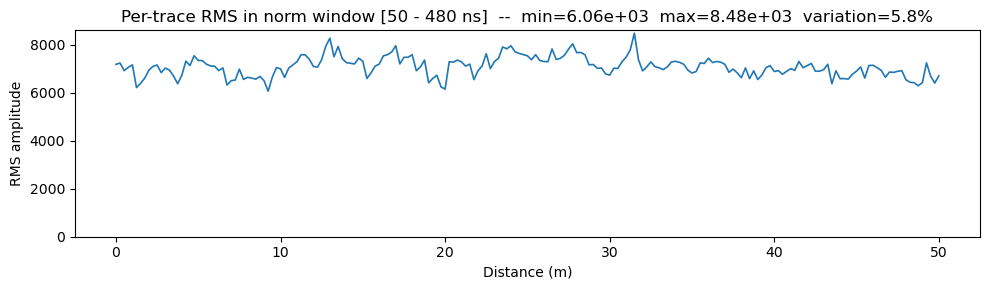

In [8]:
# Per-trace RMS in the normalisation window
# If the curve is flat, coupling is already uniform and RMS norm has no effect.
# If it has peaks or trends, norm will visibly correct them.
import matplotlib.pyplot as plt

ns_start = float(w_norm_range.value[0])
ns_end   = float(w_norm_range.value[1])
i_start  = int(np.searchsorted(time_axis, ns_start))
i_end    = int(np.searchsorted(time_axis, ns_end))

rms_per_trace = np.sqrt(np.mean(data[i_start:i_end, :]**2, axis=0))

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(dist_axis, rms_per_trace, lw=1.2)
ax.set_xlabel(f"Distance ({info['Pos_units']})")
ax.set_ylabel('RMS amplitude')
ax.set_title(
    f'Per-trace RMS in norm window [{ns_start:.0f} - {ns_end:.0f} ns]'
    f'  --  min={rms_per_trace.min():.3g}  max={rms_per_trace.max():.3g}'
    f'  variation={rms_per_trace.std()/rms_per_trace.mean()*100:.1f}%'
)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

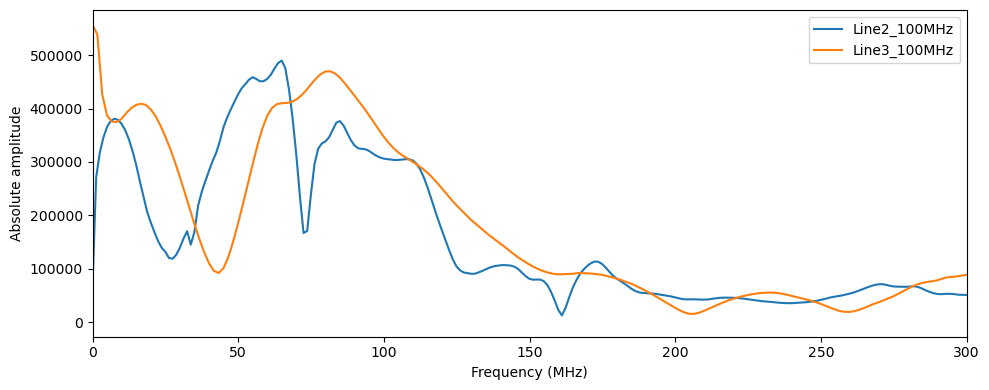

In [9]:
import matplotlib.pyplot as plt

# run this after loading each line, collect results manually
# or load multiple npz files at once:

lines = {
    'Line2_100MHz': '../../Data/GPR/Stitched/Line2_100MHz_raw.npz',
    'Line3_100MHz': '../../Data/GPR/Stitched/Line3_100MHz_raw.npz',  # adjust names
}

fig, ax = plt.subplots(figsize=(10, 4))
for name, path in lines.items():
    d = np.load(path)
    trace = d['data']
    dt = float(d['time_axis'][1] - d['time_axis'][0])
    sp = np.abs(np.fft.rfft(np.mean(trace, axis=1)))
    fr = np.fft.rfftfreq(trace.shape[0], d=dt) * 1000
    ax.plot(fr, sp, label=name)
ax.set_xlabel('Frequency (MHz)')
ax.set_ylabel('Absolute amplitude')
ax.set_xlim(0, 300)
ax.legend()
plt.tight_layout()
plt.show()


## 3. Save
Save the processed array and current slider settings. Use **Load params** on a future session to restore exactly where you left off.

In [5]:
# -- Save processed data and parameters ----------------------------------------
out_save = widgets.Output()

def _params():
    return {
        'source_file':     w_file.value,
        'dewow_window':    int(w_dewow.value),
        'tzero_shift':     float(w_tzero.value),
        'bandpass_low':    float(w_flow.value),
        'bandpass_high':   float(w_fhigh.value),
        'gain_exponent':   float(w_gain.value),
        'clip_percentile': float(w_clip.value),
        'velocity_mns':    float(w_velocity.value),
        'show_depth':      bool(w_depth_toggle.value),
        'normalize':       bool(w_normalize.value),
        'norm_start_ns':   float(w_norm_range.value[0]),
        'norm_end_ns':     float(w_norm_range.value[1]),
        'max_time_ns':     float(w_time_max.value) if w_time_max.value > 0 else None,
        'n_svd':           int(w_svd.value),
        'whiten_window':   int(w_whiten_window.value),
    }

def _save_processed(_=None):
    out_save.clear_output(wait=True)
    with out_save:
        if data is None:
            print('No data loaded.')
            return
        stem = w_file.value.replace('_raw.npz', '')
        p    = _params()
        PROC_DIR.mkdir(parents=True, exist_ok=True)

        processed, time_axis_save = apply_processing(
            p['dewow_window'], p['tzero_shift'],
            p['bandpass_low'], p['bandpass_high'], p['gain_exponent'],
            normalize=p.get('normalize', False),
            norm_start_ns=p.get('norm_start_ns', 50.0),
            norm_end_ns=p.get('norm_end_ns', None),
            max_time_ns=p.get('max_time_ns', None),
            n_svd=p.get('n_svd', 0),
            whiten_window=p.get('whiten_window', 0),
        )

        npz_path  = PROC_DIR / f'{stem}_processed.npz'
        json_path = PROC_DIR / f'{stem}_params.json'

        np.savez(str(npz_path), data=processed, dist_axis=dist_axis, time_axis=time_axis_save)
        with open(str(json_path), 'w', encoding='utf-8') as f:
            json.dump(p, f, indent=2)

        print(f'Saved .npz : {npz_path.resolve()}')
        print(f'Saved .json: {json_path.resolve()}')
        print(f'Array shape: {processed.shape}')

def _load_params(_=None):
    out_save.clear_output(wait=True)
    with out_save:
        stem      = w_file.value.replace('_raw.npz', '')
        json_path = PROC_DIR / f'{stem}_params.json'
        if not json_path.exists():
            print(f'No saved params found: {json_path}')
            return
        with open(str(json_path), encoding='utf-8') as f:
            p = json.load(f)

        w_dewow.value  = p['dewow_window']
        w_tzero.value  = p['tzero_shift']
        w_fhigh.min    = 1
        w_fhigh.max    = nyquist * 0.95
        w_fhigh.min    = p['bandpass_low']
        w_fhigh.value  = p['bandpass_high']
        w_flow.max     = p['bandpass_low']
        w_flow.value   = p['bandpass_low']
        w_gain.value   = p['gain_exponent']
        w_clip.value   = p.get('clip_percentile', 90)
        w_velocity.value  = p.get('velocity_mns', 0.13)
        w_normalize.value = p.get('normalize', False)
        ns_start = float(p.get('norm_start_ns', 50.0))
        ns_end   = float(p.get('norm_end_ns', None) or w_norm_range.max)
        w_norm_range.value = [min(ns_start, w_norm_range.max),
                               min(ns_end,   w_norm_range.max)]
        w_time_max.value      = p.get('max_time_ns', None) or 0.0
        w_svd.value           = p.get('n_svd', 0)
        w_whiten_window.value = p.get('whiten_window', 0)
        print(f"Loaded params from {json_path.name}")

btn_save    = widgets.Button(description='Save processed', button_style='success', layout=widgets.Layout(width='150px'))
btn_load_p  = widgets.Button(description='Load params',    button_style='info',    layout=widgets.Layout(width='130px'))
btn_save.on_click(_save_processed)
btn_load_p.on_click(_load_params)

display(widgets.VBox([
    widgets.HTML('<b>Save / load params</b>'),
    widgets.HBox([btn_save, btn_load_p]),
    out_save,
]))